Nós correspondentes aos centros de transporte: [4802041702, 4802041702, 502266954, 526583388, 6415251470, 526584094, 301417577, 529774383, 2345317028, 6157431741, 1826735609, 542883894, 535426343, 542883831, 505815719, 7065483873, 316330427, 5675338318, 558075056, 577609690, 7155226585, 582092128, 505815719, 4743276553, 4743276553, 3143838669, 7048166632, 8629802980, 8629802980, 526559716, 1277537350]
Rotas da MST: [(4802041702, 529774383), (502266954, 526584094), (502266954, 5675338318), (526583388, 1277537350), (526583388, 526584094), (6415251470, 577609690), (6415251470, 526559716), (526584094, 558075056), (301417577, 8629802980), (301417577, 2345317028), (529774383, 1277537350), (529774383, 526559716), (6157431741, 1277537350), (1826735609, 7065483873), (1826735609, 505815719), (542883894, 542883831), (542883894, 535426343), (535426343, 7065483873), (542883831, 4743276553), (542883831, 582092128), (505815719, 316330427), (505815719, 8629802980), (577609690, 7155226585), (577609690,

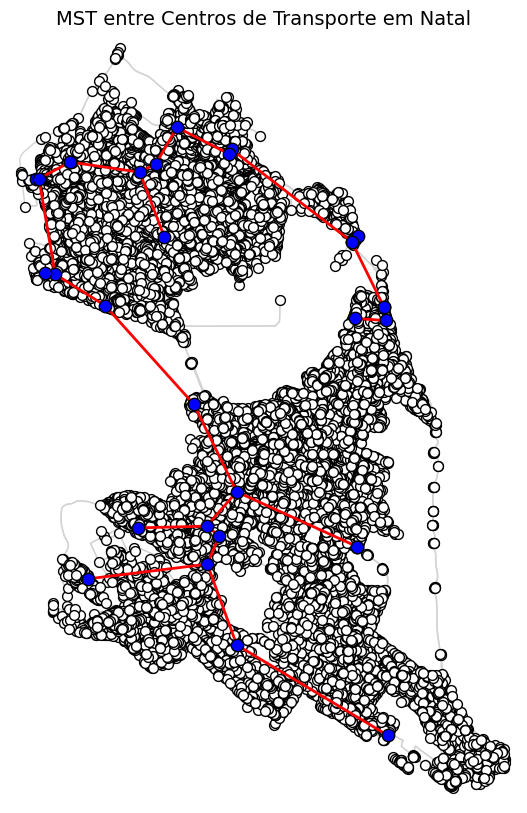

In [12]:
# Instalação e importação das bibliotecas necessárias
!pip install osmnx
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

# ============================================
# Função para converter MultiDiGraph para MultiGraph
# ============================================
def to_undirected_multigraph(G):
    """
    Converte um MultiDiGraph direcionado em um MultiGraph não-direcionado,
    preservando atributos dos nós e arestas.
    """
    H = nx.MultiGraph()
    # Copiar nós e seus atributos
    for n, data in G.nodes(data=True):
        H.add_node(n, **data)

    # Copiar arestas e seus atributos, sem direcionamento
    for u, v, data in G.edges(data=True):
        H.add_edge(u, v, **data)

    # Copiar atributos do grafo
    H.graph.update(G.graph)
    return H

# ============================================
# 1. Obter o grafo da cidade de Natal
# ============================================
place = "Natal, Rio Grande do Norte, Brazil"
G = ox.graph_from_place(place, network_type='drive')

# Converte para não-direcionado mantendo o tipo MultiGraph
G_undirected = to_undirected_multigraph(G)

# ============================================
# 2. Obter grandes centros de transporte (terminais, estações)
# ============================================
tags = {'amenity': ['bus_station', 'train_station', 'airport']}
pois = ox.features.features_from_place(place, tags=tags)

# Extrair pontos representativos (centroides se for polígono)
transport_points = []
for idx, row in pois.iterrows():
    if row.geometry.geom_type == 'Point':
        transport_points.append((row.geometry.y, row.geometry.x))
    else:
        transport_points.append((row.geometry.centroid.y, row.geometry.centroid.x))

if not transport_points:
    raise ValueError("Nenhum grande centro de transporte encontrado na região especificada.")

# ============================================
# 3. Mapear os PoIs para os nós do grafo
# ============================================
transport_nodes = []
for lat, lon in transport_points:
    nearest_node = ox.distance.nearest_nodes(G_undirected, X=lon, Y=lat)
    transport_nodes.append(nearest_node)

print(f"Nós correspondentes aos centros de transporte: {transport_nodes}")

# ============================================
# 4. Criar um grafo completo com distâncias entre os centros de transporte
# ============================================
# Criar um grafo vazio
transport_graph = nx.Graph()

# Adicionar as menores distâncias entre os pares de nós
for i in range(len(transport_nodes)):
    for j in range(i + 1, len(transport_nodes)):
        node1 = transport_nodes[i]
        node2 = transport_nodes[j]
        # Calcular a menor distância entre os nós
        length = nx.shortest_path_length(G_undirected, source=node1, target=node2, weight='length')
        # Adicionar aresta ao grafo dos PoIs
        transport_graph.add_edge(node1, node2, weight=length)

# ============================================
# 5. Aplicar o Algoritmo de Kruskal para calcular a MST
# ============================================
mst = nx.minimum_spanning_tree(transport_graph, algorithm='kruskal')
mst_routes = list(mst.edges())

print("Rotas da MST:", mst_routes)

# ============================================
# 6. Plotar a MST sobre o grafo original
# ============================================
# Obter coordenadas dos centros de transporte
transport_latitudes = [G_undirected.nodes[node]['y'] for node in transport_nodes]
transport_longitudes = [G_undirected.nodes[node]['x'] for node in transport_nodes]

# Plotar o grafo original
fig, ax = ox.plot_graph(
    G_undirected,
    show=False,
    close=False,
    node_color='white',
    node_edgecolor='black',
    node_size=50,
    edge_color='lightgray',
    edge_linewidth=1,
    bgcolor='white',
    figsize=(10, 10)
)

# Destacar as rotas do MST em vermelho
for route in mst_routes:
    x = [G_undirected.nodes[n]['x'] for n in route]
    y = [G_undirected.nodes[n]['y'] for n in route]
    ax.plot(x, y, color='red', linewidth=2, zorder=4)

# Plotar os centros de transporte (terminais, estações) em azul
ax.scatter(transport_longitudes, transport_latitudes, c='blue', s=80, zorder=5, edgecolor='black')

plt.title("MST entre Centros de Transporte em Natal", fontsize=14)
plt.show()
